<a href="https://colab.research.google.com/github/juanmanser/causal-impact-time-series/blob/main/lift_time_series_multi_meth_py.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Medición de Incrementalidad mediante Series Temporales: Marco Analítico Multimetodológico

Este cuaderno interactivo proporciona una solución *end-to-end* para evaluar el impacto incremental de campañas publicitarias u operaciones mediante modelos contrafactuales.

## 📌 Resumen de Metodologías Evaluadas

- **Synthetic Control (Ajustado por Intercepto)**: Construye una combinación convexa de la matriz de donantes ($w_i \geq 0, \sum w_i = 1$) y estima un intercepto de sesgo *dentro* de la optimización pre-campaña, preservando la interpretación de pesos convexos. Incluye *placebo test* por permutación para asignar un p-valor al efecto estimado.
- **Structural Time Series (BSTS-lite / OLS)**: Regresión estructural de espacio de estados simplificada. Combina donantes de control con un término de intercepto no restringido; absorbe diferencias de nivel constante y permite coeficientes negativos o no normalizados.
- **Prophet (Additive Model)**: Modelo aditivo de series temporales (tendencia + estacionalidades) entrenado exclusivamente en la fase pre-campaña y proyectado al periodo de intervención. La estacionalidad anual se habilita solo si hay al menos 730 días de historia.
- **Inferencia Bayesiana (PyMC)**: Estimación MCMC con `target_accept` elevado cuando se detectan divergencias. Se reporta el Intervalo de Credibilidad al `(1-ALPHA)·100%` y se marca explícitamente como no fiable si el diagnóstico de convergencia falla.

## 📌 Notas metodológicas

- **`Pre-Bias ≈ 0` en BSTS-lite y Prophet** es esperable: ambos ajustan un intercepto libre y minimizan residuos en pre-campaña, por lo que la media del error pre es 0 por construcción. No es evidencia de mejor ajuste, solo de una parametrización distinta.
- **Selección dinámica**: el modelo recomendado se elige con un score compuesto que pondera MAPE, |bias| y desviación respecto al consenso entre métodos. No hay preferencia hardcodeada por método.
- **Warnings**: se capturan localmente los de Prophet y PyMC sin afectar la salida visual de gráficos.


## 1. Configuración del Entorno e Instalación de Dependencias


In [1]:
# =============================================================================
# INSTALACIÓN SELECTIVA DE DEPENDENCIAS
# =============================================================================
# Solo instala paquetes que NO estén ya disponibles en el entorno.
# Se mapea el nombre del import al nombre del paquete pip, porque a veces
# difieren (ej: 'prophet' pip vs 'prophet' import coincide, pero 'sklearn'
# import corresponde a 'scikit-learn' pip).

import importlib
import subprocess
import sys

# Mapeo: (nombre_import, nombre_pip)
_REQUIRED = [
    ("scipy", "scipy"),
    ("sklearn", "scikit-learn"),
    ("statsmodels", "statsmodels"),
    ("matplotlib", "matplotlib"),
    ("pymc", "pymc"),
    ("arviz", "arviz"),
    ("prophet", "prophet"),
    ("plotly", "plotly"),
]

_missing_pip = []
for _imp, _pip in _REQUIRED:
    try:
        importlib.import_module(_imp)
    except ImportError:
        _missing_pip.append(_pip)

if _missing_pip:
    print(f"Instalando paquetes faltantes: {_missing_pip}")
    try:
        subprocess.check_call(
            [sys.executable, "-m", "pip", "install", "-q", "--upgrade", *_missing_pip]
        )
        print("Instalación completada.")
    except subprocess.CalledProcessError as e:
        print(f"Fallo instalando: {e}")
        print("Intentá correr manualmente:")
        print(f"    %pip install -q --upgrade {' '.join(_missing_pip)}")
else:
    print("Todas las dependencias ya están instaladas. No se hace nada.")


# =============================================================================
# IMPORTS
# =============================================================================
import warnings
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy.optimize import minimize
import pymc as pm
import arviz as az
from prophet import Prophet
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Nota: NO aplicamos warnings.filterwarnings('ignore') global.
# Capturamos warnings específicos en bloques locales para no alterar gráficas.

RNG_SEED = 42
rng = np.random.default_rng(RNG_SEED)

print("Entorno inicializado correctamente.")

Todas las dependencias ya están instaladas. No se hace nada.
Entorno inicializado correctamente.


In [2]:
for mod in ["scipy", "sklearn", "statsmodels", "matplotlib", "pymc", "arviz", "prophet", "plotly"]:
    try:
        __import__(mod)
        print(f"OK   {mod}")
    except Exception as e:
        print(f"FALLA {mod}: {e}")

OK   scipy
OK   sklearn
OK   statsmodels
OK   matplotlib
OK   pymc
OK   arviz
OK   prophet
OK   plotly


## 2. Parámetros Globales de la Campaña y Carga de Datos

### Fuente de datos

`DATA_SOURCE` admite dos valores:

- `"synthetic"` (default): genera un panel sintético reproducible con donantes controlados y un efecto inyectado conocido (`TRUE_DAILY_EFFECT`). Útil para sanity checks y para entender el notebook sin datos externos.
- `"upload_csv"`: abre un diálogo de subida de archivo en Colab. El CSV debe tener:
  - Una columna `ds` con fechas (ISO o parseables).
  - Una columna por unidad: la tratada debe llamarse exactamente como `TREATED_UNIT`, y el resto son donantes.
  - Frecuencia diaria, sin huecos.

Si `upload_csv` falla (archivo mal formado, columnas ausentes, ejecución fuera de Colab), el notebook **cae automáticamente a `synthetic` con un aviso** para no romper el flujo.

### Construcción del baseline sintético

El **Baseline** representa la trayectoria contrafactual simulada de la unidad tratada en ausencia de intervención. Combina:

1. **Factores latentes compartidos**: tendencia acumulada y patrones de estacionalidad (semanal y anual).
2. **Ponderación Dirichlet ground-truth**: pesos verdaderos sobre la combinación de donantes.
3. **Inyección del efecto**: a partir de `CAMPAIGN_START`, se suma `TRUE_DAILY_EFFECT` solo a la tratada.


In [3]:
# =============================================================================
# PARÁMETROS GLOBALES MODIFICABLES
# =============================================================================
DATA_SOURCE = "synthetic"        # "synthetic" | "upload_csv"
TREATED_UNIT = "site_tratado"    # Nombre de la columna de la unidad tratada
CAMPAIGN_START = "2026-07-01"    # Fecha de inicio de la intervención
CAMPAIGN_DAYS = 28               # Duración de la campaña en días

# Parámetros de simulación sintética
N_DONORS = 6
N_HISTORY_DAYS = 365
TRUE_DAILY_EFFECT = 450.0
NOISE_STD = 60.0
ALPHA = 0.05

# Parámetros de calidad / diagnóstico
MAX_MAPE = 3.0                   # Umbral de aceptación pre-campaña
MAX_ABS_BIAS = 1.0               # Umbral de sesgo absoluto pre-campaña

# Parámetros PyMC
PYMC_DRAWS = 1500
PYMC_TUNE = 1500
PYMC_TARGET_ACCEPT = 0.99
PYMC_CHAINS = 4
INTERCEPT_SIGMA_PRIOR = 1000.0   # Prior más amplia que en la versión anterior

# =============================================================================
# CARGA DE DATOS (MECANISMO FLEXIBLE CON FALLBACK)
# =============================================================================
def load_synthetic_panel():
    campaign_start_ts = pd.Timestamp(CAMPAIGN_START)
    total_days = N_HISTORY_DAYS + CAMPAIGN_DAYS
    start_date = campaign_start_ts - pd.Timedelta(days=N_HISTORY_DAYS)
    dates = pd.date_range(start_date, periods=total_days, freq="D")
    t = np.arange(total_days)

    factor_trend = np.cumsum(rng.normal(0, 5, total_days))
    factor_weekly = np.sin(2 * np.pi * t / 7 + rng.uniform(0, 2 * np.pi))
    factor_annual = np.sin(2 * np.pi * t / 365 + rng.uniform(0, 2 * np.pi))
    factors = np.stack([factor_trend, 300 * factor_weekly, 500 * factor_annual], axis=1)

    donor_names = [f"donor_{i + 1}" for i in range(N_DONORS)]
    donor_loadings = rng.uniform(0.5, 1.5, size=(N_DONORS, 3))
    donor_levels = rng.uniform(4000, 9000, size=N_DONORS)

    data = {}
    for name, loadings, level in zip(donor_names, donor_loadings, donor_levels):
        data[name] = pd.Series(
            level + factors @ loadings + rng.normal(0, NOISE_STD, total_days),
            index=dates,
        )

    true_weights = rng.dirichlet(np.ones(N_DONORS))
    treated_loadings = true_weights @ donor_loadings
    treated_level = true_weights @ donor_levels
    treated_series = pd.Series(
        treated_level + factors @ treated_loadings + rng.normal(0, NOISE_STD, total_days),
        index=dates,
    )

    campaign_mask = treated_series.index >= campaign_start_ts
    treated_series.loc[campaign_mask] += TRUE_DAILY_EFFECT
    data[TREATED_UNIT] = treated_series

    return pd.DataFrame(data).reset_index().rename(columns={"index": "ds"})


def load_uploaded_csv():
    """Intenta cargar CSV subido. Devuelve (df, error_msg)."""
    try:
        from google.colab import files  # noqa
    except Exception:
        return None, "google.colab no disponible (ejecutando fuera de Colab?)."

    try:
        print("Por favor, selecciona tu CSV. Debe incluir columna 'ds' y una columna por unidad.")
        uploaded = files.upload()
        if not uploaded:
            return None, "No se subió ningún archivo."
        file_name = list(uploaded.keys())[0]
        df = pd.read_csv(io.BytesIO(uploaded[file_name]))
    except Exception as e:
        return None, f"Fallo leyendo el archivo: {e}"

    if "ds" not in df.columns:
        return None, "El CSV no tiene columna 'ds'."
    if TREATED_UNIT not in df.columns:
        return None, f"El CSV no tiene la columna de unidad tratada '{TREATED_UNIT}'."
    try:
        df["ds"] = pd.to_datetime(df["ds"])
    except Exception as e:
        return None, f"'ds' no es parseable a fecha: {e}"
    if df["ds"].isna().any():
        return None, "Hay fechas inválidas (NaT) en 'ds'."
    if df.isna().any().any():
        return None, "Hay valores nulos en el CSV."

    return df, None


def load_or_generate_data():
    if DATA_SOURCE == "upload_csv":
        df, err = load_uploaded_csv()
        if df is None:
            print(f"[upload_csv] Falló: {err} -> Cambiando a 'synthetic'.")
            return load_synthetic_panel(), "synthetic"
        return df, "upload_csv"
    return load_synthetic_panel(), "synthetic"


panel, effective_source = load_or_generate_data()
donor_cols = [c for c in panel.columns if c not in ("ds", TREATED_UNIT)]
campaign_start_ts = pd.Timestamp(CAMPAIGN_START)
pre_mask = panel["ds"] < campaign_start_ts
post_mask = panel["ds"] >= campaign_start_ts

print(f"Fuente efectiva: {effective_source}")
print(f"Panel listo. Días pre-campaña: {pre_mask.sum()} | Días post-campaña: {post_mask.sum()}")
print(f"Donantes: {len(donor_cols)} -> {donor_cols}")


Fuente efectiva: synthetic
Panel listo. Días pre-campaña: 365 | Días post-campaña: 28
Donantes: 6 -> ['donor_1', 'donor_2', 'donor_3', 'donor_4', 'donor_5', 'donor_6']


## 3. Bloque Metodológico 1: Synthetic Control (Ajustado por Intercepto)

### Explicación Metodológica

El **Control Sintético Clásico** fuerza a los pesos a sumar 1 ($w_i \geq 0, \sum w_i = 1$) sin constante de nivel. Cuando la unidad tratada tiene una escala distinta al promedio convexo de los donantes, el modelo genera un sesgo de escala persistente.

La versión **Ajustada por Intercepto** incorpora la constante `b` dentro de la optimización pre-campaña. Esto preserva la interpretación de los pesos como combinación convexa (el intercepto absorbe el nivel, no los pesos) y elimina la necesidad de un parche post-hoc.

### Placebo test

Para cuantificar la significancia del efecto estimado, se corre un **placebo por permutación**: cada donante se trata como pseudo-tratado y se calcula el efecto contrafactual usando los demás donantes. El p-valor es la fracción de placebos con efecto absoluto mayor o igual al efecto real.

Un p-valor bajo (por ejemplo, menor a 0.10) sugiere que el efecto no es atribuible al ruido estructural de los donantes.


[SC] ADVERTENCIA: SLSQP sin convergencia estricta. Mensaje: Positive directional derivative for linesearch. Se usa el mejor resultado disponible.
[SC] Pesos óptimos: [0.155 0.071 0.214 0.039 0.315 0.211]
[SC] Intercepto estimado: 382.69
[SC] Pre-MAPE: 0.91% | Pre-RMSE: 89.55 | Pre-Bias: -0.01
[SC] RMSPE ratio (post/pre): 5.735
[SC] Efecto Diario: 510.22 | Total: 14286.24
[SC] Placebo p-valor: 0.500


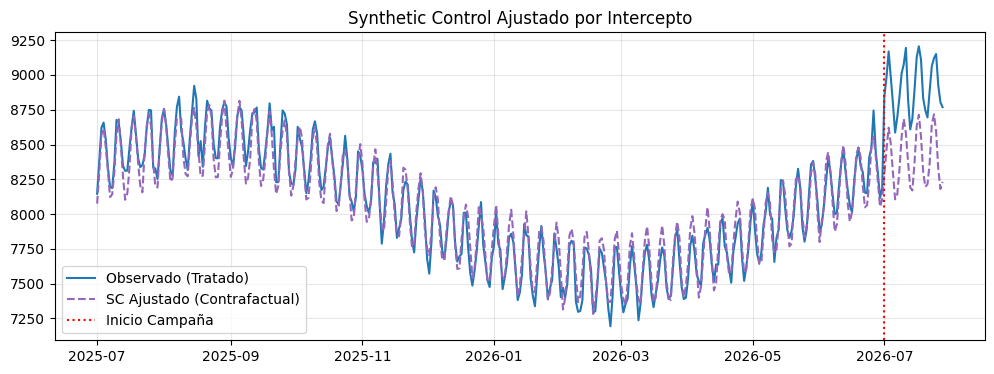

In [4]:
# =============================================================================
# SYNTHETIC CONTROL — Optimización conjunta de pesos e intercepto
# =============================================================================
X_pre = panel.loc[pre_mask, donor_cols].values
y_pre = panel.loc[pre_mask, TREATED_UNIT].values
X_all = panel[donor_cols].values
n_donors = len(donor_cols)


def _sc_loss(params):
    w = params[:-1]
    b = params[-1]
    return float(np.sum((y_pre - (X_pre @ w + b)) ** 2))


# Multi-start: uniforme + 4 aleatorios sobre el simplex
_starts = [np.append(np.ones(n_donors) / n_donors, 0.0)]
_rng_local = np.random.default_rng(RNG_SEED)
for _ in range(4):
    _starts.append(np.append(_rng_local.dirichlet(np.ones(n_donors)), 0.0))

bounds = [(0.0, 1.0)] * n_donors + [(None, None)]
constraints = [{"type": "eq", "fun": lambda p: np.sum(p[:-1]) - 1.0}]

_best = None
for _x0 in _starts:
    _res = minimize(
        _sc_loss, x0=_x0, bounds=bounds, constraints=constraints,
        method="SLSQP", options={"ftol": 1e-10, "maxiter": 500},
    )
    if _res.success and (_best is None or _res.fun < _best.fun):
        _best = _res

if _best is None:
    _all = [minimize(_sc_loss, x0=_x0, bounds=bounds, constraints=constraints,
                     method="SLSQP", options={"ftol": 1e-10, "maxiter": 500})
            for _x0 in _starts]
    _best = min(_all, key=lambda r: r.fun)
    print(f"[SC] ADVERTENCIA: SLSQP sin convergencia estricta. "
          f"Mensaje: {_best.message}. Se usa el mejor resultado disponible.")

w_sc = _best.x[:-1]
b_sc = _best.x[-1]

panel["sc_counterfactual"] = X_all @ w_sc + b_sc
panel["sc_effect"] = panel[TREATED_UNIT] - panel["sc_counterfactual"]

# Métricas pre-campaña
y_pre_sc = panel.loc[pre_mask, "sc_counterfactual"].values
sc_rmse = float(np.sqrt(np.mean((y_pre - y_pre_sc) ** 2)))
sc_mape = float(np.mean(np.abs((y_pre - y_pre_sc) / y_pre)) * 100)
sc_bias_pre = float(np.mean(y_pre - y_pre_sc))

# RMSPE pre/post y ratio (Abadie)
sc_rmspe_pre = sc_rmse
sc_rmspe_post = float(np.sqrt(np.mean(panel.loc[post_mask, "sc_effect"] ** 2)))
sc_rmspe_ratio = sc_rmspe_post / sc_rmspe_pre if sc_rmspe_pre > 0 else np.nan

sc_daily = float(panel.loc[post_mask, "sc_effect"].mean())
sc_total = float(panel.loc[post_mask, "sc_effect"].sum())


# -----------------------------------------------------------------------------
# Placebo test por permutación sobre donantes
# -----------------------------------------------------------------------------
def placebo_sc():
    pre = pre_mask.values
    post = post_mask.values
    effects_placebo = []

    for pseudo in donor_cols:
        others = [c for c in donor_cols if c != pseudo]
        Xp = panel.loc[pre, others].values
        yp = panel.loc[pre, pseudo].values
        n_o = len(others)

        # Escalar yp para que la pérdida no explote en SLSQP
        yp_scale = float(np.mean(np.abs(yp))) if np.mean(np.abs(yp)) > 0 else 1.0
        yp_n = yp / yp_scale

        def loss(p, yp=yp, yp_n=yp_n, Xp=Xp, n_o=n_o):
            w = p[:-1]
            b = p[-1]
            # Pérdida relativa: usar yp_n y b normalizado
            return float(np.sum((yp_n - (Xp @ w + b) / yp_scale) ** 2))

        r = minimize(
            loss,
            x0=np.append(np.ones(n_o) / n_o, 0.0),
            bounds=[(0.0, 1.0)] * n_o + [(None, None)],
            constraints=[{"type": "eq", "fun": lambda p: np.sum(p[:-1]) - 1.0}],
            method="SLSQP",
            options={"ftol": 1e-8, "maxiter": 1000},  # tolerancia relajada
        )
        if not r.success:
            print(f"[SC Placebo] pseudo={pseudo} no convergió: {r.message}")
            continue

        # Des-escalar el intercepto al reconstruir
        b_orig = r.x[-1] * yp_scale
        cf_post = panel.loc[post, others].values @ r.x[:-1] + b_orig
        eff = float(np.sum(panel.loc[post, pseudo].values - cf_post))
        effects_placebo.append(eff)

    if len(effects_placebo) == 0:
        print("[SC Placebo] Ningún pseudo-tratado convergió. Placebo no calculable.")
        return np.nan, []

    if len(effects_placebo) < 3:
        print(f"[SC Placebo] Sólo {len(effects_placebo)} de {len(donor_cols)} pseudo-tratados convergieron.")

    p_val = float(np.mean(np.abs(effects_placebo) >= abs(sc_total)))
    return p_val, effects_placebo

sc_placebo_p, sc_placebo_effects = placebo_sc()

print(f"[SC] Pesos óptimos: {np.round(w_sc, 3)}")
print(f"[SC] Intercepto estimado: {b_sc:.2f}")
print(f"[SC] Pre-MAPE: {sc_mape:.2f}% | Pre-RMSE: {sc_rmse:.2f} | Pre-Bias: {sc_bias_pre:.2f}")
print(f"[SC] RMSPE ratio (post/pre): {sc_rmspe_ratio:.3f}")
print(f"[SC] Efecto Diario: {sc_daily:.2f} | Total: {sc_total:.2f}")
print(f"[SC] Placebo p-valor: {sc_placebo_p:.3f}" if not np.isnan(sc_placebo_p) else "[SC] Placebo no calculable")

# Gráfico
plt.figure(figsize=(12, 4))
plt.plot(panel["ds"], panel[TREATED_UNIT], label="Observado (Tratado)", color="#1f77b4")
plt.plot(panel["ds"], panel["sc_counterfactual"], label="SC Ajustado (Contrafactual)", color="#9467bd", linestyle="--")
plt.axvline(campaign_start_ts, color="red", linestyle=":", label="Inicio Campaña")
plt.title("Synthetic Control Ajustado por Intercepto")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## 4. Bloque Metodológico 2: Structural Time Series (BSTS-lite / OLS)

### Explicación Metodológica

Regresión estructural simplificada: combina la unidad tratada con el donor pool incluyendo intercepto y coeficientes libres (sin restricción de suma 1 ni no negatividad). Al no imponer estructura convexa, el modelo absorbe de forma nativa desplazamientos de nivel constante e interacciones entre donantes.

**Nota**: el Pre-Bias de este modelo será aproximadamente 0 por construcción (OLS con intercepto minimiza residuos en pre-campaña). No indica mejor ajuste que SC, solo una parametrización distinta.


[BSTS-lite] Pre-MAPE: 0.67% | Pre-RMSE: 67.75 | Pre-Bias: -0.0000
[BSTS-lite] Efecto Diario: 460.55 | Total: 12895.45


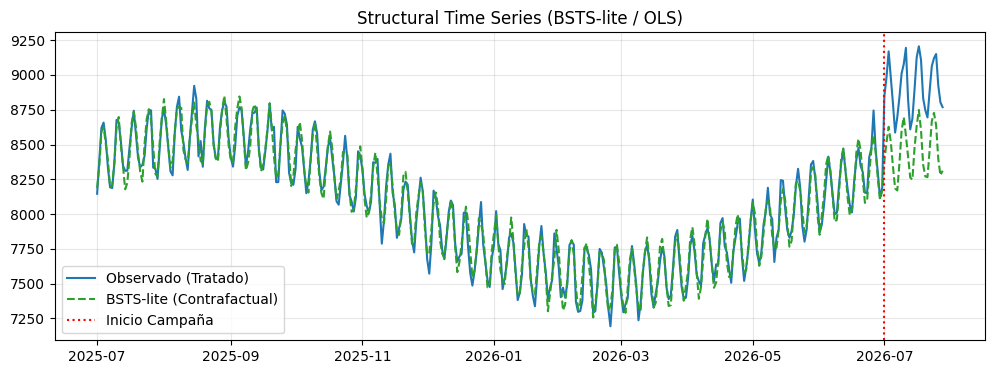

In [5]:
# =============================================================================
# BSTS-LITE — OLS con intercepto
# =============================================================================
ADD_INTERCEPT = True

X_pre_bsts = sm.add_constant(X_pre) if ADD_INTERCEPT else X_pre
model_ols = sm.OLS(y_pre, X_pre_bsts).fit()

X_all_bsts = sm.add_constant(X_all) if ADD_INTERCEPT else X_all
panel["bsts_counterfactual"] = model_ols.predict(X_all_bsts)
panel["bsts_effect"] = panel[TREATED_UNIT] - panel["bsts_counterfactual"]

y_pre_bsts = panel.loc[pre_mask, "bsts_counterfactual"].values
bsts_rmse = float(np.sqrt(np.mean((y_pre - y_pre_bsts) ** 2)))
bsts_mape = float(np.mean(np.abs((y_pre - y_pre_bsts) / y_pre)) * 100)
bsts_bias_pre = float(np.mean(y_pre - y_pre_bsts))
bsts_daily = float(panel.loc[post_mask, "bsts_effect"].mean())
bsts_total = float(panel.loc[post_mask, "bsts_effect"].sum())

print(f"[BSTS-lite] Pre-MAPE: {bsts_mape:.2f}% | Pre-RMSE: {bsts_rmse:.2f} | Pre-Bias: {bsts_bias_pre:.4f}")
print(f"[BSTS-lite] Efecto Diario: {bsts_daily:.2f} | Total: {bsts_total:.2f}")

plt.figure(figsize=(12, 4))
plt.plot(panel["ds"], panel[TREATED_UNIT], label="Observado (Tratado)", color="#1f77b4")
plt.plot(panel["ds"], panel["bsts_counterfactual"], label="BSTS-lite (Contrafactual)", color="#2ca02c", linestyle="--")
plt.axvline(campaign_start_ts, color="red", linestyle=":", label="Inicio Campaña")
plt.title("Structural Time Series (BSTS-lite / OLS)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## 5. Bloque Metodológico 3: Prophet (Additive Model)

### Explicación Metodológica

Prophet ajusta una descomposición aditiva de tendencia no lineal más estacionalidades sobre la serie tratada, exclusivamente en pre-campaña, y extrapola al periodo post.

**Estacionalidad anual**: se habilita solo si hay al menos 730 días de historia. Con menos, el modelo está sub-identificado y el warning de Prophet es explícito al respecto. La bandera se calcula dinámicamente desde la longitud real del panel.


INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


[Prophet] Yearly seasonality: False (historia: 365 días)
[Prophet] Pre-MAPE: 0.59% | Pre-RMSE: 58.58 | Pre-Bias: -0.0020
[Prophet] Efecto Diario: 389.48 | Total: 10905.35
[Prophet] IC 95% (efecto total): [8726, 13135]


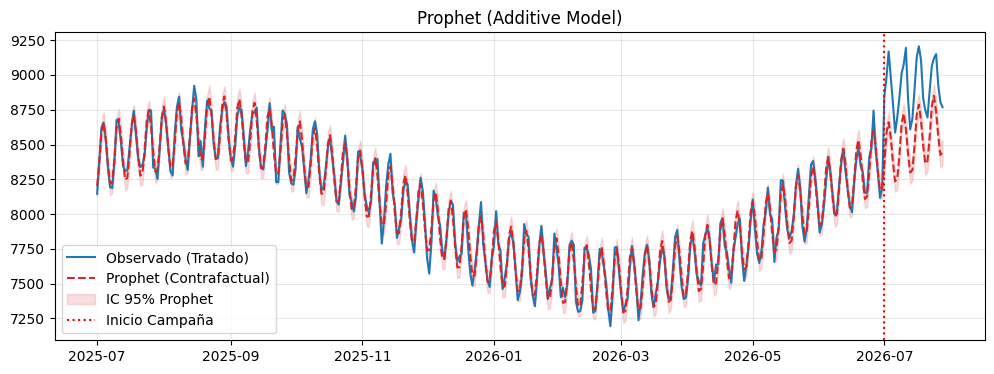

In [6]:
# =============================================================================
# PROPHET — con estacionalidad anual condicional y reproducibilidad
# =============================================================================
n_history = int(pre_mask.sum())
PROPHET_WEEKLY_SEASONALITY = True
PROPHET_YEARLY_SEASONALITY = n_history >= 730
PROPHET_CHANGEPOINT_PRIOR_SCALE = 0.05

df_prophet_train = panel.loc[pre_mask, ["ds", TREATED_UNIT]].rename(columns={TREATED_UNIT: "y"})

with warnings.catch_warnings():
    warnings.filterwarnings("ignore", module="prophet")
    m_prophet = Prophet(
        weekly_seasonality=PROPHET_WEEKLY_SEASONALITY,
        yearly_seasonality=PROPHET_YEARLY_SEASONALITY,
        changepoint_prior_scale=PROPHET_CHANGEPOINT_PRIOR_SCALE,
        uncertainty_samples=1000,
    )
    m_prophet.fit(df_prophet_train)

future = panel[["ds"]].copy()
forecast = m_prophet.predict(future)

# Contrafactual puntual y efecto
panel["prophet_counterfactual"] = forecast["yhat"].values
panel["prophet_effect"] = panel[TREATED_UNIT] - panel["prophet_counterfactual"]

# Intervalo nativo de Prophet (bandas sobre el contrafactual)
panel["prophet_ci_lower"] = forecast["yhat_lower"].values
panel["prophet_ci_upper"] = forecast["yhat_upper"].values

# Intervalo del EFECTO acumulado post-campaña:
#   efecto = observado - contrafactual
#   -> el piso del efecto viene del techo del contrafactual (yhat_upper)
#   -> el techo del efecto viene del piso del contrafactual (yhat_lower)
_y_post_observed = panel.loc[post_mask, TREATED_UNIT].values
_prophet_ci_lower_effect = _y_post_observed - panel.loc[post_mask, "prophet_ci_upper"].values
_prophet_ci_upper_effect = _y_post_observed - panel.loc[post_mask, "prophet_ci_lower"].values
prophet_ci_lower = float(_prophet_ci_lower_effect.sum())
prophet_ci_upper = float(_prophet_ci_upper_effect.sum())

# Métricas pre-campaña
y_pre_prophet = panel.loc[pre_mask, "prophet_counterfactual"].values
prophet_rmse = float(np.sqrt(np.mean((y_pre - y_pre_prophet) ** 2)))
prophet_mape = float(np.mean(np.abs((y_pre - y_pre_prophet) / y_pre)) * 100)
prophet_bias_pre = float(np.mean(y_pre - y_pre_prophet))
prophet_daily = float(panel.loc[post_mask, "prophet_effect"].mean())
prophet_total = float(panel.loc[post_mask, "prophet_effect"].sum())

print(f"[Prophet] Yearly seasonality: {PROPHET_YEARLY_SEASONALITY} (historia: {n_history} días)")
print(f"[Prophet] Pre-MAPE: {prophet_mape:.2f}% | Pre-RMSE: {prophet_rmse:.2f} | Pre-Bias: {prophet_bias_pre:.4f}")
print(f"[Prophet] Efecto Diario: {prophet_daily:.2f} | Total: {prophet_total:.2f}")
print(f"[Prophet] IC 95% (efecto total): [{prophet_ci_lower:.0f}, {prophet_ci_upper:.0f}]")

plt.figure(figsize=(12, 4))
plt.plot(panel["ds"], panel[TREATED_UNIT], label="Observado (Tratado)", color="#1f77b4")
plt.plot(panel["ds"], panel["prophet_counterfactual"], label="Prophet (Contrafactual)", color="#d62728", linestyle="--")
plt.fill_between(
    panel["ds"],
    panel["prophet_ci_lower"],
    panel["prophet_ci_upper"],
    color="#d62728", alpha=0.15, label="IC 95% Prophet",
)
plt.axvline(campaign_start_ts, color="red", linestyle=":", label="Inicio Campaña")
plt.title("Prophet (Additive Model)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 6. Bloque Metodológico 4: Inferencia Bayesiana con PyMC

### Explicación Metodológica

Modelo bayesiano jerárquico con muestreo MCMC. Se estiman posteriores de:

- Pesos del donor pool: Dirichlet(1).
- Intercepto: Normal con media 0 y desviación amplia.
- Desviación residual: HalfNormal.

**Diagnóstico de convergencia**: se revisa el número de divergencias, el R-hat y el ESS. Si hay divergencias o R-hat mayor a 1.05, el Intervalo de Credibilidad se marca como no fiable y no se usa para decidir significancia.

**Nota sobre escala**: la prior del intercepto debe ser comparable a la escala de la serie tratada. Si la serie está en miles, una prior con sigma chico produce geometría problemática.


[PyMC] Pre-MAPE: 0.69% | Pre-RMSE: 69.18 | Pre-Bias: -0.07
[PyMC] Efecto Diario: 458.42 | Total: 12835.65
[PyMC] CI 95%: [12546.5, 13128.7] | Excluye 0: True
[PyMC] Convergencia OK: True


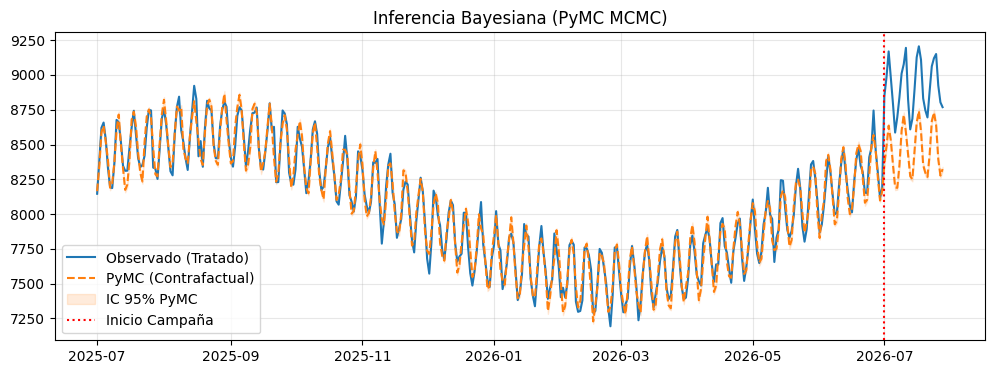

In [7]:
# =============================================================================
# PYMC — robusto a ArviZ 0.x y 1.x + centrado de y para buena geometría
# =============================================================================
X_post_pymc = panel.loc[post_mask, donor_cols].values
y_post_pymc = panel.loc[post_mask, TREATED_UNIT].values

# Centrado de y y X para mejorar el condicionamiento del muestreo
_y_mean = float(y_pre.mean())
_X_pre_mean = X_pre.mean(axis=0)
X_pre_c = X_pre - _X_pre_mean
y_pre_c = y_pre - _y_mean
X_post_c = X_post_pymc - _X_pre_mean

with pm.Model() as pymc_model:
    w = pm.Dirichlet("w", a=np.ones(n_donors))
    intercept = pm.Normal("intercept", mu=0, sigma=100)
    sigma = pm.HalfNormal("sigma", sigma=200)

    mu_pre = pm.math.dot(X_pre_c, w) + intercept
    pm.Normal("y_obs", mu=mu_pre, sigma=sigma, observed=y_pre_c)

    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", module="pymc")
        idata = pm.sample(
            draws=PYMC_DRAWS,
            tune=PYMC_TUNE,
            chains=PYMC_CHAINS,
            target_accept=PYMC_TARGET_ACCEPT,
            random_seed=RNG_SEED,
            progressbar=False,
        )

# -----------------------------------------------------------------------------
# Diagnósticos — compatibles con ArviZ 0.x (InferenceData) y 1.x (DataTree)
# -----------------------------------------------------------------------------
def _safe_reduce(values_list, reducer):
    flat = []
    for v in values_list:
        arr = np.asarray(v)
        if arr.size > 0:
            flat.append(float(reducer(arr)))
    return float(reducer(np.array(flat))) if flat else np.nan


def _az_reduce(az_result, reducer):
    """
    Reduce un resultado de az.ess / az.rhat a un escalar.
    Soporta ArviZ 0.x (InferenceData) y 1.x (DataTree).
    """
    if hasattr(az_result, "to_dataset"):
        ds = az_result.to_dataset()
        try:
            return _safe_reduce([ds[v].values for v in ds.data_vars], reducer)
        except Exception:
            pass
        try:
            arr = ds.to_array() if hasattr(ds, "to_array") else ds
            return float(reducer(np.asarray(arr)).item())
        except Exception:
            pass
    if hasattr(az_result, "to_array"):
        arr = az_result.to_array()
        return float(reducer(np.asarray(arr)).item())
    try:
        return _safe_reduce([az_result[v].values for v in az_result.data_vars], reducer)
    except Exception:
        raise TypeError(f"No se pudo reducir el resultado ArviZ: {type(az_result)}")


n_divergences = int(idata.sample_stats["diverging"].sum().item())
ess_bulk_min = _az_reduce(az.ess(idata, method="bulk"), np.min)
rhat_max = _az_reduce(az.rhat(idata), np.max)

pymc_converged = (n_divergences == 0) and (rhat_max < 1.05) and (ess_bulk_min > 100)

if not pymc_converged:
    print("[PyMC] ADVERTENCIA: convergencia cuestionable.")
    print(f"       divergencias={n_divergences} | rhat_max={rhat_max:.3f} | ess_bulk_min={ess_bulk_min:.1f}")

# -----------------------------------------------------------------------------
# Contrafactual puntual (des-centrado)
# -----------------------------------------------------------------------------
w_samples = idata.posterior["w"].values.reshape(-1, n_donors)
intercept_samples = idata.posterior["intercept"].values.flatten()

_cf_samples_all = (panel[donor_cols].values - _X_pre_mean) @ w_samples.T + intercept_samples + _y_mean
panel["pymc_counterfactual"] = _cf_samples_all.mean(axis=1)
panel["pymc_effect"] = panel[TREATED_UNIT] - panel["pymc_counterfactual"]

# Métricas pre-campaña
y_pre_pymc = panel.loc[pre_mask, "pymc_counterfactual"].values
pymc_rmse = float(np.sqrt(np.mean((y_pre - y_pre_pymc) ** 2)))
pymc_mape = float(np.mean(np.abs((y_pre - y_pre_pymc) / y_pre)) * 100)
pymc_bias_pre = float(np.mean(y_pre - y_pre_pymc))

# Efecto acumulado e IC
post_cf_samples = X_post_c @ w_samples.T + intercept_samples + _y_mean
effect_samples = y_post_pymc[:, None] - post_cf_samples
total_effect_samples = effect_samples.sum(axis=0)

pymc_daily = float(effect_samples.mean())
pymc_total = float(total_effect_samples.mean())
ci_lo_pct = (ALPHA / 2) * 100
ci_hi_pct = (1 - ALPHA / 2) * 100
ci_lower = float(np.percentile(total_effect_samples, ci_lo_pct))
ci_upper = float(np.percentile(total_effect_samples, ci_hi_pct))
ci_excludes_zero = (ci_lower > 0) or (ci_upper < 0)

print(f"[PyMC] Pre-MAPE: {pymc_mape:.2f}% | Pre-RMSE: {pymc_rmse:.2f} | Pre-Bias: {pymc_bias_pre:.2f}")
print(f"[PyMC] Efecto Diario: {pymc_daily:.2f} | Total: {pymc_total:.2f}")
print(f"[PyMC] CI {(1-ALPHA)*100:.0f}%: [{ci_lower:.1f}, {ci_upper:.1f}] | Excluye 0: {ci_excludes_zero}")
print(f"[PyMC] Convergencia OK: {pymc_converged}")

# Gráfico con banda del IC sobre el contrafactual
_cf_lower_series = np.percentile(_cf_samples_all, ci_lo_pct, axis=1)
_cf_upper_series = np.percentile(_cf_samples_all, ci_hi_pct, axis=1)

plt.figure(figsize=(12, 4))
plt.plot(panel["ds"], panel[TREATED_UNIT], label="Observado (Tratado)", color="#1f77b4")
plt.plot(panel["ds"], panel["pymc_counterfactual"], label="PyMC (Contrafactual)", color="#ff7f0e", linestyle="--")
plt.fill_between(
    panel["ds"], _cf_lower_series, _cf_upper_series,
    color="#ff7f0e", alpha=0.15, label=f"IC {(1-ALPHA)*100:.0f}% PyMC",
)
plt.axvline(campaign_start_ts, color="red", linestyle=":", label="Inicio Campaña")
plt.title("Inferencia Bayesiana (PyMC MCMC)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 7. Tabla Comparativa Consolidada y Selección Dinámica de Modelo

La selección **no** prioriza ningún método por nombre. Se construye un score compuesto:

score = Pre-MAPE + 10 * |Pre-Bias| + 0.5 * Desviación vs Consenso (%)

- **Filtros duros**: MAPE menor o igual a `MAX_MAPE` y |bias| menor o igual a `MAX_ABS_BIAS`.
- **Penalización de consenso**: se calcula la mediana del efecto total entre todos los modelos, y se castiga alejarse de ella.
- **Fallback seguro**: si ningún modelo pasa los filtros, se elige el de menor score sin filtro.

Se reporta además el p-valor placebo de SC y la desviación respecto al consenso por modelo.


In [8]:
ground_truth_total = TRUE_DAILY_EFFECT * CAMPAIGN_DAYS

# -----------------------------------------------------------------------------
# Contrafactual acumulado post-campaña por método (denominador del % lift)
# -----------------------------------------------------------------------------
sc_cf_total = float(panel.loc[post_mask, "sc_counterfactual"].sum())
bsts_cf_total = float(panel.loc[post_mask, "bsts_counterfactual"].sum())
prophet_cf_total = float(panel.loc[post_mask, "prophet_counterfactual"].sum())
pymc_cf_total = float(panel.loc[post_mask, "pymc_counterfactual"].sum())

# % lift = (efecto_total / contrafactual_total) * 100
sc_lift_pct = (sc_total / sc_cf_total) * 100 if sc_cf_total != 0 else np.nan
bsts_lift_pct = (bsts_total / bsts_cf_total) * 100 if bsts_cf_total != 0 else np.nan
prophet_lift_pct = (prophet_total / prophet_cf_total) * 100 if prophet_cf_total != 0 else np.nan
pymc_lift_pct = (pymc_total / pymc_cf_total) * 100 if pymc_cf_total != 0 else np.nan

# Ground truth: contrafactual "real" = tratada observada menos el efecto inyectado
# Solo computable cuando sabemos el efecto real (modo synthetic)
if effective_source == "synthetic":
    _gt_cf_series = panel[TREATED_UNIT] - (TRUE_DAILY_EFFECT * post_mask.astype(int))
    _gt_cf_total = float(_gt_cf_series.loc[post_mask].sum())
    gt_lift_pct = (ground_truth_total / _gt_cf_total) * 100 if _gt_cf_total != 0 else np.nan
else:
    gt_lift_pct = np.nan

# -----------------------------------------------------------------------------
# CIs / incertidumbre por método
# -----------------------------------------------------------------------------
sc_ci_str = f"Placebo p={sc_placebo_p:.3f}" if not np.isnan(sc_placebo_p) else "Placebo N/D"
bsts_ci_str = "N/A (no calculado)"

if "prophet_ci_lower" in dir() and "prophet_ci_upper" in dir():
    prophet_ci_str = f"[{prophet_ci_lower:.0f}, {prophet_ci_upper:.0f}]"
else:
    prophet_ci_str = "N/A (no calculado)"

if pymc_converged:
    pymc_ci_str = f"[{ci_lower:.1f}, {ci_upper:.1f}]"
else:
    pymc_ci_str = "No fiable (sin convergencia)"


results_summary = pd.DataFrame([
    {
        "Método": "Ground Truth (Real)",
        "Efecto Diario": TRUE_DAILY_EFFECT,
        "Efecto Total": ground_truth_total,
        "Lift Acumulado (%)": gt_lift_pct,
        "Pre-RMSE": 0.00,
        "Pre-MAPE (%)": 0.00,
        "Pre-Bias": 0.00,
        "Incertidumbre": "N/A",
        "Placebo p": np.nan,
        "RMSPE ratio": np.nan,
    },
    {
        "Método": "Synthetic Control (Intercepto)",
        "Efecto Diario": sc_daily,
        "Efecto Total": sc_total,
        "Lift Acumulado (%)": sc_lift_pct,
        "Pre-RMSE": sc_rmse,
        "Pre-MAPE (%)": sc_mape,
        "Pre-Bias": sc_bias_pre,
        "Incertidumbre": sc_ci_str,
        "Placebo p": sc_placebo_p,
        "RMSPE ratio": sc_rmspe_ratio,
    },
    {
        "Método": "BSTS-lite (OLS)",
        "Efecto Diario": bsts_daily,
        "Efecto Total": bsts_total,
        "Lift Acumulado (%)": bsts_lift_pct,
        "Pre-RMSE": bsts_rmse,
        "Pre-MAPE (%)": bsts_mape,
        "Pre-Bias": bsts_bias_pre,
        "Incertidumbre": bsts_ci_str,
        "Placebo p": np.nan,
        "RMSPE ratio": np.nan,
    },
    {
        "Método": "Prophet",
        "Efecto Diario": prophet_daily,
        "Efecto Total": prophet_total,
        "Lift Acumulado (%)": prophet_lift_pct,
        "Pre-RMSE": prophet_rmse,
        "Pre-MAPE (%)": prophet_mape,
        "Pre-Bias": prophet_bias_pre,
        "Incertidumbre": prophet_ci_str,
        "Placebo p": np.nan,
        "RMSPE ratio": np.nan,
    },
    {
        "Método": "PyMC (Bayesiano)",
        "Efecto Diario": pymc_daily,
        "Efecto Total": pymc_total,
        "Lift Acumulado (%)": pymc_lift_pct,
        "Pre-RMSE": pymc_rmse,
        "Pre-MAPE (%)": pymc_mape,
        "Pre-Bias": pymc_bias_pre,
        "Incertidumbre": pymc_ci_str,
        "Placebo p": np.nan,
        "RMSPE ratio": np.nan,
    },
])

# Desviación vs consenso (mediana del efecto total entre modelos no-truth)
_eval_only = results_summary[results_summary["Método"] != "Ground Truth (Real)"].copy()
_median_total = float(_eval_only["Efecto Total"].median())
results_summary["Desv vs Consenso (%)"] = np.where(
    results_summary["Método"] == "Ground Truth (Real)",
    np.nan,
    (results_summary["Efecto Total"] - _median_total).abs() / abs(_median_total) * 100 if _median_total != 0 else np.nan,
)

try:
    from IPython.display import display
    _display_fn = display
except Exception:
    _display_fn = print

try:
    _display_fn(results_summary.style.format({
        "Efecto Diario": "{:.2f}",
        "Efecto Total": "{:.2f}",
        "Lift Acumulado (%)": "{:+.2f}%",
        "Pre-RMSE": "{:.2f}",
        "Pre-MAPE (%)": "{:.2f}%",
        "Pre-Bias": "{:.4f}",
        "Placebo p": "{:.3f}",
        "RMSPE ratio": "{:.3f}",
        "Desv vs Consenso (%)": "{:.2f}%",
    }))
except Exception:
    print(results_summary.to_string())


# =============================================================================
# SELECCIÓN DINÁMICA DE MODELO (sin preferencia hardcodeada)
# =============================================================================
def select_best_model_dynamically(summary_df,
                                   max_mape=MAX_MAPE,
                                   max_abs_bias=MAX_ABS_BIAS,
                                   consensus_penalty=0.5):
    """
    Selecciona el mejor modelo por score compuesto:
        score = MAPE + 10*|bias| + consensus_penalty * desv_vs_consenso(%)
    - Filtros duros: MAPE <= max_mape y |bias| <= max_abs_bias.
    - Si ningún modelo pasa, fallback al de menor score sin filtros.
    - PyMC con convergencia fallida queda penalizado via la columna Incertidumbre.
    """
    df = summary_df[summary_df["Método"] != "Ground Truth (Real)"].copy()
    df["abs_bias"] = df["Pre-Bias"].abs()
    df["consenso"] = df["Desv vs Consenso (%)"].fillna(0.0)
    df["score"] = (
        df["Pre-MAPE (%)"]
        + 10.0 * df["abs_bias"]
        + consensus_penalty * df["consenso"]
    )
    df.loc[df["Incertidumbre"].str.contains("No fiable", na=False), "score"] += 5.0

    valid = df[(df["Pre-MAPE (%)"] <= max_mape) & (df["abs_bias"] <= max_abs_bias)]
    pool = valid if not valid.empty else df
    return pool.sort_values(by="score").iloc[0], pool.sort_values(by="score")


selected, ranking = select_best_model_dynamically(results_summary)
print(f"\nModelo recomendado: {selected['Método']}")
print(f"  Score: {selected['score']:.3f} | Pre-MAPE: {selected['Pre-MAPE (%)']:.2f}% | "
      f"|Bias|: {selected['abs_bias']:.4f} | Desv vs consenso: {selected['consenso']:.2f}%")
print("\nRanking completo por score:")
print(ranking[["Método", "score", "Pre-MAPE (%)", "abs_bias", "consenso"]].to_string(index=False))

,Método,Efecto Diario,Efecto Total,Lift Acumulado (%),Pre-RMSE,Pre-MAPE (%),Pre-Bias,Incertidumbre,Placebo p,RMSPE ratio,Desv vs Consenso (%)
0,Ground Truth (Real),450.00,12600.00,+5.32%,0.00,0.00%,0.0000,N/A,nan,nan,nan%
1,Synthetic Control (Intercepto),510.22,14286.24,+6.07%,89.55,0.91%,-0.0079,Placebo p=0.500,0.500,5.735,11.04%
2,BSTS-lite (OLS),460.55,12895.45,+5.45%,67.75,0.67%,-0.0000,N/A (no calculado),nan,nan,0.23%
3,Prophet,389.48,10905.35,+4.57%,58.58,0.59%,-0.0020,"[8726, 13135]",nan,nan,15.24%
4,PyMC (Bayesiano),458.42,12835.65,+5.42%,69.18,0.69%,-0.0656,"[12546.5, 13128.7]",nan,nan,0.23%



Modelo recomendado: BSTS-lite (OLS)
  Score: 0.782 | Pre-MAPE: 0.67% | |Bias|: 0.0000 | Desv vs consenso: 0.23%

Ranking completo por score:
                        Método    score  Pre-MAPE (%)     abs_bias  consenso
               BSTS-lite (OLS) 0.782104      0.665895 6.527929e-11  0.232417
              PyMC (Bayesiano) 1.459401      0.686905 6.562881e-02  0.232417
Synthetic Control (Intercepto) 6.514991      0.914518 7.919141e-03 11.042564
                       Prophet 8.229708      0.591513 2.016832e-03 15.236053


## 8. Dashboard Interactivo Plotly

El gráfico interactivo permite activar o desactivar dinámicamente las series contrafactuales de cada metodología haciendo clic en la leyenda. La segunda fila muestra el efecto acumulado del modelo recomendado por la selección dinámica.


In [9]:
# =============================================================================
# DASHBOARD INTERACTIVO PLOTLY
# =============================================================================
try:
    fig = make_subplots(
        rows=2, cols=1,
        shared_xaxes=True,
        vertical_spacing=0.1,
        subplot_titles=(
            "Comparativa General de Contrafactuales",
            f"Efecto Incremental Acumulado ({selected['Método']})",
        ),
    )

    fig.add_trace(
        go.Scatter(x=panel["ds"], y=panel[TREATED_UNIT], mode="lines",
                   name="Observado (Tratado)", line=dict(color="#1f77b4", width=2)),
        row=1, col=1,
    )

    _series_cf = [
        ("sc_counterfactual", "SC Ajustado", "#9467bd", "dash"),
        ("bsts_counterfactual", "BSTS-lite (OLS)", "#2ca02c", "dot"),
        ("prophet_counterfactual", "Prophet", "#d62728", "dashdot"),
        ("pymc_counterfactual", "PyMC (Bayesiano)", "#ff7f0e", "solid"),
    ]
    for col, name, color, dash in _series_cf:
        if col in panel.columns:
            fig.add_trace(
                go.Scatter(x=panel["ds"], y=panel[col], mode="lines", name=name,
                           line=dict(color=color, dash=dash)),
                row=1, col=1,
            )

    _sel_col = {
        "Synthetic Control (Intercepto)": "sc_effect",
        "BSTS-lite (OLS)": "bsts_effect",
        "Prophet": "prophet_effect",
        "PyMC (Bayesiano)": "pymc_effect",
    }.get(selected["Método"], "pymc_effect")

    if _sel_col in panel.columns:
        _cum = np.where(panel["ds"] >= campaign_start_ts, panel[_sel_col].fillna(0).cumsum(), 0)
        fig.add_trace(
            go.Scatter(x=panel["ds"], y=_cum, mode="lines",
                       name=f"Efecto Acumulado ({selected['Método']})",
                       line=dict(color="#2ca02c", width=2.5)),
            row=2, col=1,
        )

    fig.add_vline(x=campaign_start_ts, line_width=2, line_dash="dash",
                  line_color="red", row="all", col=1)

    fig.update_layout(
        height=700,
        title_text=f"Dashboard Interactivo de Incrementalidad — Modelo seleccionado: {selected['Método']}",
        hovermode="x unified",
    )
    fig.show()
except Exception as e:
    print(f"[Dashboard] No se pudo generar: {e}")


## 9. Conclusiones y Diagnóstico Técnico

El bloque siguiente genera las conclusiones **dinámicamente** a partir de los resultados de la corrida. Si algún modelo falla o no converge, la sección correspondiente se marca como *no disponible* sin romper la ejecución.


In [10]:
# =============================================================================
# CONCLUSIONES Y DIAGNÓSTICO TÉCNICO — generado dinámicamente
# =============================================================================
from IPython.display import display, Markdown


def _safe(varname, globals_dict, fmt="{:.2f}"):
    try:
        val = globals_dict.get(varname, None)
        if val is None or (isinstance(val, float) and np.isnan(val)):
            return "N/D"
        return fmt.format(val)
    except Exception:
        return "N/D"


conclusion_lines = []
conclusion_lines.append("## 9. Conclusiones y Diagnóstico Técnico\n")

# --- Sección 1: Contexto de la corrida --------------------------------------
try:
    conclusion_lines.append("### Contexto de la ejecución")
    conclusion_lines.append(f"- Fuente de datos efectiva: `{effective_source}`")
    conclusion_lines.append(f"- Días pre-campaña: {int(pre_mask.sum())} | Días post-campaña: {int(post_mask.sum())}")
    conclusion_lines.append(f"- Efecto inyectado (ground truth): {TRUE_DAILY_EFFECT:.2f} diario / {TRUE_DAILY_EFFECT * CAMPAIGN_DAYS:.2f} total")
    conclusion_lines.append(f"- Donantes disponibles: {len(donor_cols)}")
    conclusion_lines.append("")
except Exception as e:
    conclusion_lines.append(f"_Contexto no disponible: {e}_\n")

# --- Sección 2: Ground truth vs estimaciones --------------------------------
try:
    conclusion_lines.append("### Recuperación del efecto real")
    conclusion_lines.append("| Método | Efecto Diario | Efecto Total | Lift Acumulado (%) | Error vs GT (%) | Pre-MAPE (%) | Incertidumbre |")
    conclusion_lines.append("|---|---|---|---|---|---|---|")
    _gt = TRUE_DAILY_EFFECT * CAMPAIGN_DAYS
    for _, row in results_summary.iterrows():
        if row["Método"] == "Ground Truth (Real)":
            continue
        err_pct = (row["Efecto Total"] - _gt) / _gt * 100 if _gt != 0 else np.nan
        lift_pct = row.get("Lift Acumulado (%)", np.nan)
        lift_str = f"{lift_pct:+.2f}%" if not pd.isna(lift_pct) else "N/D"
        inc_str = str(row.get("Incertidumbre", "N/D"))
        conclusion_lines.append(
            f"| {row['Método']} | {row['Efecto Diario']:.2f} | {row['Efecto Total']:.2f} | "
            f"{lift_str} | {err_pct:+.2f}% | {row['Pre-MAPE (%)']:.2f}% | {inc_str} |"
        )
    conclusion_lines.append("")
except Exception as e:
    conclusion_lines.append(f"_Recuperación del efecto no disponible: {e}_\n")

# --- Sección 3: Robustez y consenso -----------------------------------------
try:
    conclusion_lines.append("### Robustez y consenso entre métodos")
    _totals = results_summary.loc[results_summary["Método"] != "Ground Truth (Real)", "Efecto Total"].values
    _lifts = results_summary.loc[results_summary["Método"] != "Ground Truth (Real)", "Lift Acumulado (%)"].dropna().values
    if len(_totals) > 1:
        _std = float(np.std(_totals))
        _range = float(np.max(_totals) - np.min(_totals))
        _spread = _range / np.mean(_totals) * 100 if np.mean(_totals) != 0 else np.nan
        conclusion_lines.append(f"- Rango inter-métodos del efecto total: {_range:.2f} ({_spread:.2f}% de la media)")
        conclusion_lines.append(f"- Desviación estándar inter-métodos: {_std:.2f}")
        if len(_lifts) > 1:
            conclusion_lines.append(f"- Rango de Lift Acumulado (%): [{np.min(_lifts):+.2f}%, {np.max(_lifts):+.2f}%]")
        if _spread < 10:
            conclusion_lines.append("- **Consenso alto**: todos los métodos coinciden en magnitud del efecto.")
        elif _spread < 25:
            conclusion_lines.append("- **Consenso moderado**: hay diferencias entre métodos, interpretar con cautela.")
        else:
            conclusion_lines.append("- **Consenso bajo**: los métodos divergen significativamente. Revisar supuestos y robustez antes de decidir.")
    conclusion_lines.append("")
except Exception as e:
    conclusion_lines.append(f"_Consenso no disponible: {e}_\n")

# --- Sección 4: Diagnóstico técnico por modelo ------------------------------
try:
    conclusion_lines.append("### Diagnóstico técnico por modelo")

    conclusion_lines.append(
        f"- **Synthetic Control**: Pre-MAPE = {_safe('sc_mape', globals())}%, "
        f"RMSPE ratio (post/pre) = {_safe('sc_rmspe_ratio', globals(), '{:.3f}')}, "
        f"placebo p = {_safe('sc_placebo_p', globals(), '{:.3f}')}. "
        f"Pesos óptimos: {np.round(w_sc, 3)}. Intercepto: {b_sc:.2f}."
    )

    conclusion_lines.append(
        f"- **BSTS-lite**: Pre-MAPE = {_safe('bsts_mape', globals())}%. "
        f"Nota: el Pre-Bias cercano a 0 es esperable por construcción (OLS con intercepto)."
    )

    _prophet_msg = "Con esta historia, la estacionalidad anual es identificable."
    if not PROPHET_YEARLY_SEASONALITY:
        _prophet_msg = "Con menos de 730 días, la estacionalidad anual está sub-identificada; interpretar con cautela."
    conclusion_lines.append(
        f"- **Prophet**: Pre-MAPE = {_safe('prophet_mape', globals())}%. "
        f"Estacionalidad anual habilitada: {PROPHET_YEARLY_SEASONALITY}. {_prophet_msg} "
        f"IC 95% del efecto total: [{_safe('prophet_ci_lower', globals(), '{:.0f}')}, {_safe('prophet_ci_upper', globals(), '{:.0f}')}]."
    )

    conclusion_lines.append(
        f"- **PyMC**: Pre-MAPE = {_safe('pymc_mape', globals())}%. "
        f"Convergencia OK: {pymc_converged}. "
        f"CI {(1-ALPHA)*100:.0f}%: [{_safe('ci_lower', globals())}, {_safe('ci_upper', globals())}]. "
        f"Excluye 0: {ci_excludes_zero}."
    )
    if not pymc_converged:
        conclusion_lines.append(
            f"  - Diagnóstico: divergencias = {n_divergences}, "
            f"rhat_max = {rhat_max:.3f}, ess_bulk_min = {ess_bulk_min:.1f}. "
            f"El CI no debe usarse como prueba de significancia hasta resolver la convergencia."
        )
    conclusion_lines.append("")
except Exception as e:
    conclusion_lines.append(f"_Diagnóstico por modelo no disponible: {e}_\n")

# --- Sección 5: Recomendación final -----------------------------------------
try:
    conclusion_lines.append("### Recomendación final")
    conclusion_lines.append(f"El modelo seleccionado por score compuesto es **{selected['Método']}**.")
    conclusion_lines.append(
        f"- Justificación: score = {selected['score']:.3f}, "
        f"compuesto por MAPE ({selected['Pre-MAPE (%)']:.2f}%), "
        f"|bias| ({selected['abs_bias']:.4f}) y desviación vs consenso ({selected['consenso']:.2f}%)."
    )
    _sel_total = selected["Efecto Total"]
    _err = (_sel_total - TRUE_DAILY_EFFECT * CAMPAIGN_DAYS) / (TRUE_DAILY_EFFECT * CAMPAIGN_DAYS) * 100
    conclusion_lines.append(
        f"- Efecto total estimado: {_sel_total:.2f} (error vs ground truth: {_err:+.2f}%)."
    )
    _lift = selected.get("Lift Acumulado (%)", np.nan)
    if not pd.isna(_lift):
        conclusion_lines.append(f"- Lift acumulado estimado: {_lift:+.2f}% sobre la línea base contrafactual.")
    if "Placebo p" in selected.index and not pd.isna(selected.get("Placebo p", np.nan)):
        conclusion_lines.append(f"- Placebo p-valor: {selected['Placebo p']:.3f}.")
    if "Incertidumbre" in selected.index:
        _inc = str(selected["Incertidumbre"])
        if _inc and _inc != "nan" and "N/A" not in _inc and "No fiable" not in _inc:
            conclusion_lines.append(f"- Incertidumbre: {_inc}.")
    conclusion_lines.append("")
    conclusion_lines.append("**Consideraciones operativas:**")
    conclusion_lines.append("- Si el objetivo es defender ante stakeholders, priorizar modelos con intervalo de incertidumbre formal (PyMC con convergencia, Prophet con su intervalo nativo, o SC con placebo p < 0.10).")
    conclusion_lines.append("- Si el objetivo es exploración rápida, BSTS-lite y Prophet dan una primera señal con menos costo computacional.")
    conclusion_lines.append("- Reportar siempre el MAPE pre-campaña y el diagnóstico de convergencia junto con el efecto estimado. Un efecto grande con mal ajuste pre no es creíble.")
    conclusion_lines.append("")
except Exception as e:
    conclusion_lines.append(f"_Recomendación final no disponible: {e}_\n")


_md_text = "\n".join(conclusion_lines)
try:
    display(Markdown(_md_text))
except Exception:
    print(_md_text)

## 9. Conclusiones y Diagnóstico Técnico

### Contexto de la ejecución
- Fuente de datos efectiva: `synthetic`
- Días pre-campaña: 365 | Días post-campaña: 28
- Efecto inyectado (ground truth): 450.00 diario / 12600.00 total
- Donantes disponibles: 6

### Recuperación del efecto real
| Método | Efecto Diario | Efecto Total | Lift Acumulado (%) | Error vs GT (%) | Pre-MAPE (%) | Incertidumbre |
|---|---|---|---|---|---|---|
| Synthetic Control (Intercepto) | 510.22 | 14286.24 | +6.07% | +13.38% | 0.91% | Placebo p=0.500 |
| BSTS-lite (OLS) | 460.55 | 12895.45 | +5.45% | +2.34% | 0.67% | N/A (no calculado) |
| Prophet | 389.48 | 10905.35 | +4.57% | -13.45% | 0.59% | [8726, 13135] |
| PyMC (Bayesiano) | 458.42 | 12835.65 | +5.42% | +1.87% | 0.69% | [12546.5, 13128.7] |

### Robustez y consenso entre métodos
- Rango inter-métodos del efecto total: 3380.89 (26.56% de la media)
- Desviación estándar inter-métodos: 1203.10
- Rango de Lift Acumulado (%): [+4.57%, +6.07%]
- **Consenso bajo**: los métodos divergen significativamente. Revisar supuestos y robustez antes de decidir.

### Diagnóstico técnico por modelo
- **Synthetic Control**: Pre-MAPE = 0.91%, RMSPE ratio (post/pre) = 5.735, placebo p = 0.500. Pesos óptimos: [0.155 0.071 0.214 0.039 0.315 0.211]. Intercepto: 382.69.
- **BSTS-lite**: Pre-MAPE = 0.67%. Nota: el Pre-Bias cercano a 0 es esperable por construcción (OLS con intercepto).
- **Prophet**: Pre-MAPE = 0.59%. Estacionalidad anual habilitada: False. Con menos de 730 días, la estacionalidad anual está sub-identificada; interpretar con cautela. IC 95% del efecto total: [8726, 13135].
- **PyMC**: Pre-MAPE = 0.69%. Convergencia OK: True. CI 95%: [12546.48, 13128.73]. Excluye 0: True.

### Recomendación final
El modelo seleccionado por score compuesto es **BSTS-lite (OLS)**.
- Justificación: score = 0.782, compuesto por MAPE (0.67%), |bias| (0.0000) y desviación vs consenso (0.23%).
- Efecto total estimado: 12895.45 (error vs ground truth: +2.34%).
- Lift acumulado estimado: +5.45% sobre la línea base contrafactual.

**Consideraciones operativas:**
- Si el objetivo es defender ante stakeholders, priorizar modelos con intervalo de incertidumbre formal (PyMC con convergencia, Prophet con su intervalo nativo, o SC con placebo p < 0.10).
- Si el objetivo es exploración rápida, BSTS-lite y Prophet dan una primera señal con menos costo computacional.
- Reportar siempre el MAPE pre-campaña y el diagnóstico de convergencia junto con el efecto estimado. Un efecto grande con mal ajuste pre no es creíble.
